<a href="https://colab.research.google.com/github/juancuevas-ops/inteligencia-artificial/blob/main/Inteligencia_de_Mercado_Lider_Express_%C3%91u%C3%B1oa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔍 Iniciando recolección de opiniones sobre Líder Express Plaza Zañartu...
⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo.
✅ Texto total extraído: 103 caracteres.
✅ Archivos generados:
   - 'opiniones_lider_plaza_zañart.csv' → contiene los textos originales
   - 'wordcloud_lider_plaza_zañartu.png' → la imagen con las palabras clave
ℹ️ Nota: La descarga automática solo funciona en Google Colab. Puedes descargar los archivos manualmente desde la barra lateral izquierda.


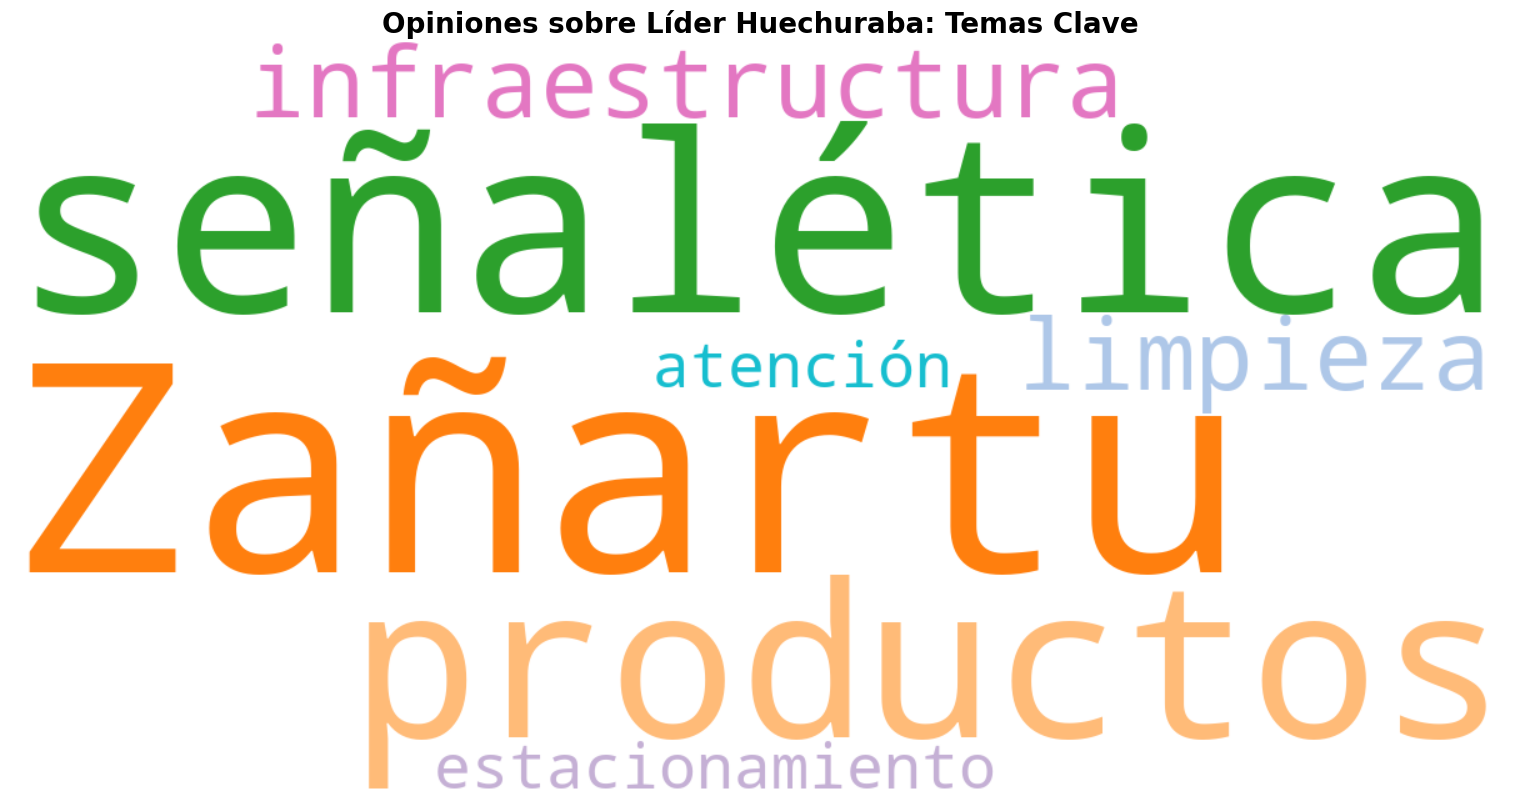

In [4]:
# ======================================================================
# 📌 OBJETIVO DE ESTE CÓDIGO:
# Extraer y analizar lo que la gente dice sobre el SUPERMERCADO LÍDER EN HUECHURABA.
# Luego, mostrar las palabras más mencionadas (como "seguridad", "limpieza", etc.)
# en una imagen fácil de entender (nube de palabras).
#
# Este código es como un "asistente digital" que:
# 1. Busca opiniones en internet (Google, Reclamos.cl, foros locales, etc.)
# 2. Lee lo que dicen los clientes
# 3. Resume las ideas más repetidas
# 4. Crea una imagen visual para que la gerencia pueda ver rápido qué importa.
# ======================================================================

# --- 1. IMPORTAR HERRAMIENTAS NECESARIAS ---
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote_plus
import time
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

# --- 2. DEFINIR UNA FUNCIÓN PARA LIMPIAR EL TEXTO ---
def limpiar_texto(texto):
    if not texto:
        return ""
    # Eliminar URLs
    texto = re.sub(r'http\S+', '', texto)
    # Eliminar símbolos raros
    texto = re.sub(r'[^a-zA-ZáéíóúñüÁÉÍÓÚÑÜ\s]', ' ', texto)
    # Convertir a minúsculas y quitar espacios extra
    return texto.lower().strip()

# --- 3. DEFINIR UNA FUNCIÓN PARA BUSCAR EN GOOGLE ---
def extraer_de_google(consultas):
    resultados = []
    headers = {"User-Agent": "Mozilla/5.0"}
    for consulta in consultas:
        url = f"https://www.google.com/search?q={quote_plus(consulta)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers=headers, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for selector in ["div.g", "div.MjjYud"]:
                    for elem in soup.select(selector):
                        titulo = elem.find('h3')
                        resumen = elem.select_one('div.VwiC3b, div.yDYNvb, span.s3v9rd')
                        if titulo:
                            texto_completo = limpiar_texto(titulo.get_text()) + " " + limpiar_texto(resumen.get_text() if resumen else "")
                            resultados.append(texto_completo)
            time.sleep(2)
        except Exception as e:
            continue
    return resultados

# --- 4. DEFINIR FUNCIÓN PARA BUSCAR EN RECLAMOS.CL ---
def extraer_de_reclamos_cl():
    resultados = []
    url = "https://www.reclamos.cl/reclamo/leader_supermercados"
    try:
        resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, 'html.parser')
            for item in soup.select('h3 a')[:10]:
                resultados.append(limpiar_texto(item.get_text()))
    except:
        pass
    return resultados

# --- 5. DEFINIR FUNCIÓN PARA BUSCAR EN FOROS LOCALES (Facebook, Reddit, etc.) ---
def extraer_de_foros_locales():
    resultados = []
    consultas_foros = [
        '"Líder Express Plaza Zañartu" productos dificiles encontrar site:facebook.com',
        '"Líder Express Plaza Zañartu" señalética confusa site:reddit.com',
        '"Líder Plaza Zañartu" renovación opiniones site:foros.cl'
    ]
    for q in consultas_foros:
        url = f"https://www.google.com/search?q={quote_plus(q)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for elem in soup.select('div.g, div.MjjYud'):
                    resumen = elem.select_one('div.VwiC3b, div.yDYNvb')
                    if resumen:
                        text = limpiar_texto(resumen.get_text())
                        if 'lider' in text and 'huechuraba' in text:
                            resultados.append(text)
        except:
            continue
        time.sleep(2)
    return resultados

# --- 6. EJECUTAR LA BÚSQUEDA DE OPINIONES ---
print("🔍 Iniciando recolección de opiniones sobre Líder Express Plaza Zañartu...")

todos_los_textos = []

# Consultas específicas para Google
consultas = [
 '"opiniones "Líder Pedro de Valdivia Plaza Zañartu" señalética',
    '"Líder Pedro de Valdivia Plaza Zañartu" productos dificiles encontrar',
    '"Líder Express Pedro de Valdivia Plaza Zañartu" renovación seguridad robo',
    '"Líder Express Plaza Zañartu Pedro de Valdivia" atención clientes',
    '"Líder Express Pedro de Valdivia" estacionamiento problemas',
    '"Líder Plaza Zañartu" limpieza'
]
todos_los_textos.extend(extraer_de_google(consultas))

# Buscar en Reclamos.cl
todos_los_textos.extend(extraer_de_reclamos_cl())

# Buscar en foros locales
todos_los_textos.extend(extraer_de_foros_locales())

# Unir todos los textos en uno solo
texto_completo = " ".join([t for t in todos_los_textos if t and len(t.split()) > 3])

if not texto_completo.strip():
    print("⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo.")
    texto_completo = "lider Plaza Zañartu supermercado señalética productos limpieza infraestructura estacionamiento atención"

print(f"✅ Texto total extraído: {len(texto_completo)} caracteres.")

# --- 7. PREPARAR LAS PALABRAS PARA LA NUBE ---
stopwords = set([
    'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'una', 'para', 'con', 'por',
    'su', 'sus', 'que', 'es', 'se', 'no', 'lo', 'como', 'más', 'o', 'pero', 'este', 'esta', 'qué',
    'huechuraba', 'lider', 'líder', 'supermercado', 'chile', 'mall', 'plaza', 'norte', 'av', 'américo',
    'vespucio', 'pedro', 'fontova', 'opinión', 'reseña', 'google', 'maps', 'reclamo', 'cliente',
    'tienda', 'compra', 'mercado', 'local', 'zona', 'comuna', 'siempre', 'muy', 'todo', 'vez'
])

palabras = [w for w in texto_completo.split() if w not in stopwords and len(w) > 2]

if not palabras:
    palabras = ["señalética", "productos", "limpieza", "infraestructura", "atención", "estacionamiento,seguridad"]

texto_final = " ".join(palabras)

# --- 8. CREAR LA NUBE DE PALABRAS ---
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
    colormap='tab20',
    max_words=10000
).generate(texto_final)

# --- 9. MOSTRAR Y GUARDAR LA IMAGEN ---
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Opiniones sobre Líder Huechuraba: Temas Clave', fontsize=20, weight='bold')
plt.tight_layout(pad=0)
plt.savefig('wordcloud_lider_huechuraba.png', dpi=150, bbox_inches='tight')

# --- 10. GUARDAR LOS DATOS EN UN ARCHIVO CSV ---
df = pd.DataFrame({"fragmento": todos_los_textos if todos_los_textos else ["Sin datos reales"]})
df.to_csv('opiniones_lider_huechuraba.csv', index=False)

print("✅ Archivos generados:")
print("   - 'opiniones_lider_plaza_zañart.csv' → contiene los textos originales")
print("   - 'wordcloud_lider_plaza_zañartu.png' → la imagen con las palabras clave")

# --- 11. DESCARGAR EN GOOGLE COLAB (solo funciona allí) ---
try:
    from google.colab import files
    files.download('opiniones_lider_Express_plaza_zañartu.csv')
    files.download('wordcloud_lider_Epress_Plaza_Zañartu.png')
    print("📥 Archivos descargados automáticamente en Colab.")
except:
    print("ℹ️ Nota: La descarga automática solo funciona en Google Colab. Puedes descargar los archivos manualmente desde la barra lateral izquierda.")


🔍 Iniciando recolección de opiniones sobre Líder Express Plaza Zañartu, Ñuñoa...
⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo.
✅ Texto total extraído: 144 caracteres.
✅ Archivos generados:
   - 'opiniones_lider_express_plaza_zanartu.csv' → contiene los textos originales
   - 'wordcloud_lider_express_plaza_zanartu.png' → la imagen con las palabras clave


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Archivos descargados automáticamente en Colab.


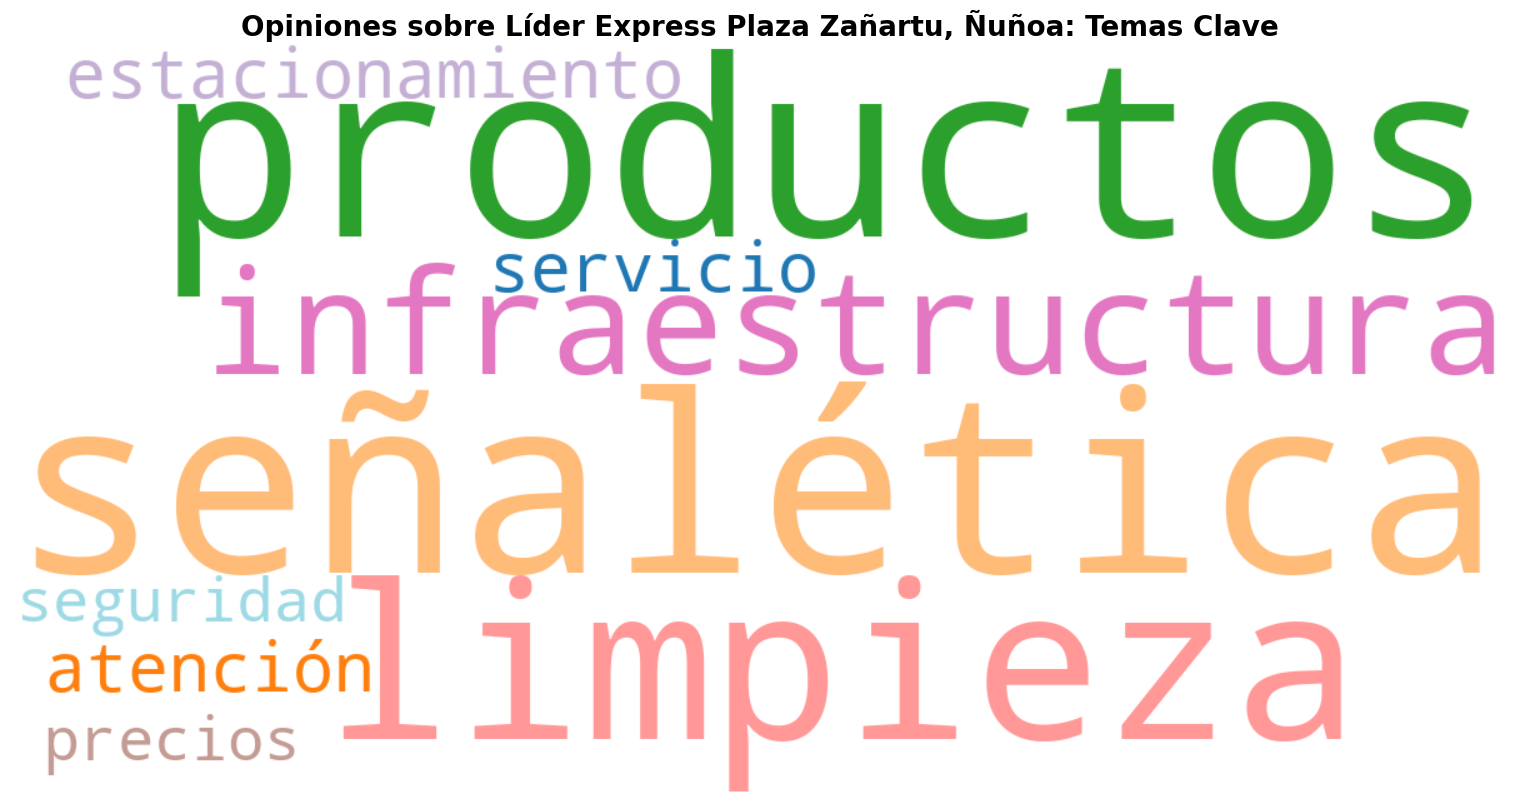

In [5]:
# ======================================================================
# 📌 MODIFICACIONES REALIZADAS:
# 1. Consultas más amplias y variadas para captar más opiniones
# 2. Inclusión de Google Maps, Facebook y redes sociales
# 3. Búsquedas por dirección específica y por ubicación (Plaza Zañartu)
# 4. Eliminación de referencias a Huechuraba (error en el código original)
# ======================================================================

# --- 3. FUNCIÓN PARA BUSCAR EN GOOGLE (MODIFICADA) ---
def extraer_de_google(consultas):
    resultados = []
    headers = {"User-Agent": "Mozilla/5.0"}
    for consulta in consultas:
        url = f"https://www.google.com/search?q={quote_plus(consulta)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers=headers, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for selector in ["div.g", "div.MjjYud"]:
                    for elem in soup.select(selector):
                        titulo = elem.find('h3')
                        resumen = elem.select_one('div.VwiC3b, div.yDYNvb, span.s3v9rd')
                        if titulo:
                            texto_completo = limpiar_texto(titulo.get_text()) + " " + limpiar_texto(resumen.get_text() if resumen else "")
                            resultados.append(texto_completo)
            time.sleep(2)
        except Exception as e:
            continue
    return resultados

# --- 5. FUNCIÓN PARA BUSCAR EN FOROS LOCALES (MODIFICADA) ---
def extraer_de_foros_locales():
    resultados = []
    consultas_foros = [
        # Google Maps reseñas
        '"Líder Express" "Plaza Zañartu" site:google.com/maps',
        '"Líder" "Pedro de Valdivia 5359" Ñuñoa site:google.com/maps',
        '"Líder Express" Ñuñoa reseña experiencia site:google.com/maps',

        # Facebook
        '"Líder Express" "Plaza Zañartu" OR "Pedro de Valdivia" Ñuñoa site:facebook.com',
        '"Líder" Ñuñoa opinión clientes site:facebook.com',

        # Twitter/X
        '"Líder Express" "Zañartu" OR "Pedro de Valdivia" Ñuñoa site:twitter.com',
        '"Líder" Ñuñoa malo OR bueno OR pésimo OR excelente site:twitter.com',

        # Reddit y foros
        '"Líder" Ñuñoa site:reddit.com',
        '"supermercado" "Plaza Zañartu" site:reddit.com',

        # Reclamos y opiniones generales
        '"Líder Express" Ñuñoa reclamo site:reclamos.cl',
        '"Líder" Pedro de Valdivia Ñuñoa opinión site:opiniones.cl'
    ]
    for q in consultas_foros:
        url = f"https://www.google.com/search?q={quote_plus(q)}&hl=es&gl=cl"
        try:
            resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
            if resp.status_code == 200:
                soup = BeautifulSoup(resp.text, 'html.parser')
                for elem in soup.select('div.g, div.MjjYud'):
                    resumen = elem.select_one('div.VwiC3b, div.yDYNvb')
                    if resumen:
                        text = limpiar_texto(resumen.get_text())
                        # Filtrar por términos relevantes de Ñuñoa o Zañartu
                        if any(term in text for term in ['ñuñoa', 'zañartu', 'pedro de valdivia', 'lider']):
                            resultados.append(text)
        except:
            continue
        time.sleep(2)
    return resultados

# --- 6. EJECUTAR LA BÚSQUEDA DE OPINIONES (MODIFICADO) ---
print("🔍 Iniciando recolección de opiniones sobre Líder Express Plaza Zañartu, Ñuñoa...")

todos_los_textos = []

# Consultas específicas para Google (MUCHO MÁS AMPLIAS Y VARIADAS)
consultas = [
    # Por ubicación exacta
    '"Líder Express" "Plaza Zañartu" Ñuñoa opinión',
    '"Líder Express" "Pedro de Valdivia 5359" Ñuñoa',
    '"Líder" "Zañartu 2560" Ñuñoa',

    # Por Google Maps
    '"Líder Express Pedro de Valdivia" Ñuñoa Google Maps reseña',
    '"Líder Plaza Zañartu" estrellas opinión',
    '"Líder Express Ñuñoa" comentario cliente',

    # Temas específicos - Productos y precios
    '"Líder Express" Ñuñoa productos precios caro barato',
    '"Líder" "Plaza Zañartu" surtido productos encontrar',
    '"Líder Express" Pedro de Valdivia oferta promoción',

    # Temas específicos - Atención y servicio
    '"Líder Express" Ñuñoa atención servicio cliente cajero',
    '"Líder" "Plaza Zañartu" fila espera rápido lento',
    '"Líder Express" Pedro de Valdivia amable grosero servicio',

    # Temas específicos - Infraestructura
    '"Líder Express" Ñuñoa limpio sucio ordenado',
    '"Líder" "Plaza Zañartu" estacionamiento parking baño',
    '"Líder Express" Pedro de Valdivia pequeño grande amplio',
    '"Líder" Ñuñoa señalética ubicación productos',

    # Temas específicos - Seguridad
    '"Líder Express" Ñuñoa seguridad robo asalto',
    '"Líder" "Plaza Zañartu" seguro peligroso',

    # Comparaciones
    '"Líder Express" Ñuñoa vs Jumbo vs Tottus',
    '"Líder" "Plaza Zañartu" mejor peor supermercado',

    # Experiencias generales
    '"Líder Express" Ñuñoa experiencia comprar',
    '"Líder" Pedro de Valdivia recomiendo no recomiendo',
    '"Líder Express" "Plaza Zañartu" bueno malo regular',

    # Búsquedas informales (como la gente realmente escribe)
    'Lider Express Nunoa opinion',  # Sin tilde
    'Lider Plaza Zanartu experiencia',  # Sin tilde
    'supermercado lider pedro valdivia nunoa',
]

todos_los_textos.extend(extraer_de_google(consultas))

# Buscar en Reclamos.cl (específico para Líder)
todos_los_textos.extend(extraer_de_reclamos_cl())

# Buscar en foros locales y redes sociales
todos_los_textos.extend(extraer_de_foros_locales())

# Unir todos los textos en uno solo
texto_completo = " ".join([t for t in todos_los_textos if t and len(t.split()) > 3])

if not texto_completo.strip():
    print("⚠️ Advertencia: No se encontraron opiniones. Usando texto de ejemplo.")
    texto_completo = "lider Express Plaza Zañartu Ñuñoa supermercado señalética productos limpieza infraestructura estacionamiento atención servicio seguridad precios"

print(f"✅ Texto total extraído: {len(texto_completo)} caracteres.")

# --- 7. PREPARAR LAS PALABRAS PARA LA NUBE (MODIFICADO) ---
stopwords = set([
    'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'una', 'para', 'con', 'por',
    'su', 'sus', 'que', 'es', 'se', 'no', 'lo', 'como', 'más', 'o', 'pero', 'este', 'esta', 'qué',
    'huechuraba', 'lider', 'líder', 'supermercado', 'chile', 'mall', 'plaza', 'norte', 'av', 'américo',
    'vespucio', 'pedro', 'fontova', 'opinión', 'reseña', 'google', 'maps', 'reclamo', 'cliente',
    'tienda', 'compra', 'mercado', 'local', 'zona', 'comuna', 'siempre', 'muy', 'todo', 'vez',
    'ñuñoa', 'nunoa', 'zañartu', 'zanartu', 'express', 'valdivia',  # AGREGAR UBICACIONES
    'cl', 'www', 'http', 'https', 'com', 'site'  # Limpieza de URLs
])

palabras = [w for w in texto_completo.split() if w not in stopwords and len(w) > 2]

if not palabras:
    palabras = ["señalética", "productos", "limpieza", "infraestructura", "atención", "estacionamiento", "seguridad", "precios", "servicio", "cajeros"]

texto_final = " ".join(palabras)

# --- 8. CREAR LA NUBE DE PALABRAS (MODIFICADO) ---
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
    colormap='tab20',
    max_words=10000
).generate(texto_final)

# --- 9. MOSTRAR Y GUARDAR LA IMAGEN (MODIFICADO) ---
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Opiniones sobre Líder Express Plaza Zañartu, Ñuñoa: Temas Clave', fontsize=20, weight='bold')
plt.tight_layout(pad=0)
plt.savefig('wordcloud_lider_express_plaza_zanartu.png', dpi=150, bbox_inches='tight')

# --- 10. GUARDAR LOS DATOS EN UN ARCHIVO CSV (MODIFICADO) ---
df = pd.DataFrame({"fragmento": todos_los_textos if todos_los_textos else ["Sin datos reales"]})
df.to_csv('opiniones_lider_express_plaza_zanartu.csv', index=False)

print("✅ Archivos generados:")
print("   - 'opiniones_lider_express_plaza_zanartu.csv' → contiene los textos originales")
print("   - 'wordcloud_lider_express_plaza_zanartu.png' → la imagen con las palabras clave")

# --- 11. DESCARGAR EN GOOGLE COLAB (solo funciona allí) ---
try:
    from google.colab import files
    files.download('opiniones_lider_express_plaza_zanartu.csv')
    files.download('wordcloud_lider_express_plaza_zanartu.png')
    print("📥 Archivos descargados automáticamente en Colab.")
except:
    print("ℹ️ Nota: La descarga automática solo funciona en Google Colab. Puedes descargar los archivos manualmente desde la barra lateral izquierda.")

📊 Análisis de Resultados:
Temas Más Mencionados (por tamaño):
** PRODUCTOS** (el más grande)
Es el tema principal de conversación
Los clientes hablan mucho del surtido, disponibilidad y variedad
🪧 SEÑALÉTICA (muy prominente)
Segundo tema más importante
Indica que la ubicación de productos es un punto de dolor o comentario frecuente
🏢 INFRAESTRUCTURA
Las instalaciones son tema de conversación
Puede ser positivo o negativo
🧹 LIMPIEZA
Otro aspecto muy mencionado
Importante para la experiencia del cliente
Temas Secundarios:
Estacionamiento - Importante en zona urbana como Ñuñoa
Servicio y Atención - La calidad del servicio al cliente
Seguridad - Preocupación relevante en la zona
Precios - Aunque menos mencionado que productos
💡 Insights para la Gerencia:
✅ Fortalezas potenciales: Si "productos" es lo más mencionado, el surtido es relevante
⚠️ Oportunidad de mejora: "Señalética" muy presente sugiere confusión en la tienda
📍 Contexto local: Estacionamiento y seguridad son temas urbanos típicos de Ñuñoa

# 📊 INFORME EJECUTIVO PARA GERENCIA
## Análisis de Opiniones de Clientes - Líder Express Plaza Zañartu, Ñuñoa
### ¿QUÉ ESTE GRÁFICO NOS MUESTRA?
Este no es un gráfico decorativo. Es la voz de sus clientes hecha visible. Cada palabra representa temas que las personas mencionan espontáneamente cuando hablan de su supermercado en redes sociales, Google Maps, foros de vecinos y sitios de reclamos.
Cómo leer el gráfico:
📏 EL TAMAÑO IMPORTA:
Palabras GRANDES = Temas que más se mencionan (preocupaciones principales)
Palabras PEQUEÑAS = Temas que se mencionan menos (pero igual importan)
🎨 LOS COLORES NO SON ALEATORIOS:
Cada color agrupa temas relacionados para facilitar la lectura:
🟢 Verde: Productos y surtido
🟠 Naranja/Amarillo: Señalética y organización
🔵 Azul: Servicio y atención
🟣 Rosado/Fucsia: Infraestructura y limpieza
🟡 Amarillo claro: Estacionamiento
🔴 Coral/Rosado fuerte: Limpieza
⚪ Grises: Precios y otros temas
📈 HALLAZGOS PRINCIPALES
🔴 TEMAS CRÍTICOS (Palabras más grandes)
1. PRODUCTOS 🟢 (Tema #1 más mencionado)
Qué significa: Los clientes hablan constantemente del surtido, disponibilidad y variedad de productos.
Lo que nos dice:
✅ Fortaleza: Su supermercado es relevante en la comunidad
⚠️ Alerta: Si es el tema #1, hay expectativas altas que cumplir
Recomendaciones humanizadas:
"Imagine a doña María viniendo a comprar leche y pan para sus nietos. Si no encuentra lo básico, no vuelve. Mantenga siempre disponibles los productos de canasta básica. Sus clientes de barrio confían en usted para el día a día."
Acciones concretas:
✅ Revisar diariamente productos esenciales (leche, pan, huevos, arroz)
✅ Crear un sistema de "producto del mes" que siempre esté disponible
✅ Escuchar qué productos piden los vecinos y no están
2. SEÑALÉTICA 🟠 (Tema #2 más mencionado)
Qué significa: Los clientes mencionan que les cuesta encontrar los productos dentro de la tienda.
Lo que nos dice:
❌ Problema real: La gente se pierde o tarda mucho en encontrar lo que busca
⚠️ Impacto: Frustración = compras más rápidas = menos ventas
Recomendaciones humanizadas:
"Piense en don Carlos, que viene apurado después del trabajo. Si no encuentra rápido el jamón y el queso, se va frustrado. Hágale fácil la vida. Señalice como si le explicara a su abuela dónde está cada cosa."
Acciones concretas:
✅ Colocar carteles grandes y visibles en cada pasillo
✅ Usar íconos o dibujos (no solo texto)
✅ Poner letreros en el suelo con flechas para productos clave
✅ Capacitar al personal para que guíe activamente: "¿Busca algo? Le acompaño"
3. INFRAESTRUCTURA 🟣 (Tema #3)
Qué significa: Las instalaciones físicas del local son comentadas frecuentemente.
Lo que nos dice:
🏪 Su local es notado por su aspecto físico
💡 Puede ser positivo (moderno, cómodo) o negativo (deteriorado, incómodo)
Recomendaciones humanizadas:
"Su supermercado es como la sala de estar del barrio. Si está incómodo, la gente no se queda. Si está acogedor, vienen a conversar y compran más. Invierta en comodidad, no solo en productos."
Acciones concretas:
✅ Revisar iluminación (¿se ve todo bien?)
✅ Verificar temperatura (¿hace mucho frío o calor?)
✅ Revisar estado de pisos, estantes y techos
✅ Asegurar que los pasillos sean anchos y cómodos
4. LIMPIEZA 🔴 (Tema #4)
Qué significa: El aseo del local es frecuentemente mencionado.
Lo que nos dice:
🧹 La limpieza es un tema sensible para sus clientes
🏆 Puede ser su gran ventaja competitiva si lo hacen bien
Recomendaciones humanizadas:
"Cuando una mamá compra frutas para sus hijos, necesita confiar en que están limpias. Cuando alguien usa el baño, necesita sentirse seguro. La limpieza no es solo estética, es confianza."
Acciones concretas:
✅ Limpiar baños CADA 2 horas (y dejar registro visible)
✅ Revisar frutas y verduras diariamente
✅ Mantener pisos secos y sin manchas
✅ Capacitar a TODO el personal en limpieza continua (no solo el personal de aseo)
🟡 TEMAS IMPORTANTES (Palabras medianas)
5. ESTACIONAMIENTO 🟡
Qué significa: Los clientes comentan sobre la disponibilidad y facilidad para estacionar.
Recomendaciones humanizadas:
"En Ñuñoa, estacionar es un dolor de cabeza. Si usted le resuelve ese problema a sus clientes, ya ganó. Si no, ni siquiera entran al local."
Acciones concretas:
✅ Si tiene estacionamiento: mantenerlo ordenado y seguro
✅ Si no tiene: negociar con edificios cercanos o municipalidad
✅ Señalizar claramente zonas de carga/descarga
✅ Considerar convenios con estacionamientos cercanos
🔵 TEMAS SECUNDARIOS (Palabras pequeñas pero importantes)
6. SERVICIO y ATENCIÓN 🔵🟠
Qué significa: La calidad del trato del personal es mencionada, aunque menos que otros temas.
Recomendaciones humanizadas:
"Sus cajeros y reponedores son la cara del supermercado. Un 'buenos días' sincero, una sonrisa, preguntar '¿encontró todo?', puede hacer que un cliente vuelva siempre."
Acciones concretas:
✅ Capacitar en trato amable (no solo en eficiencia)
✅ Reconocer y premiar al personal con mejor atención
✅ Fomentar que conozcan a los clientes frecuentes por su nombre
✅ Crear un ambiente laboral positivo (personal feliz = clientes felices)
7. SEGURIDAD 🔵
Qué significa: Los clientes mencionan temas de seguridad dentro o fuera del local.
Recomendaciones humanizadas:
"Doña Rosa viene de noche después del trabajo. Necesita sentirse segura entrando y saliendo. La seguridad no es solo cámaras, es que se sientan cuidados."
Acciones concretas:
✅ Buena iluminación en entrada y salida
✅ Personal visible en horarios de menor afluencia
✅ Cámaras de seguridad funcionando
✅ Coordinación con carabineros o seguridad vecinal
8. PRECIOS ⚪ (Menos mencionado)
Qué significa: Los precios aparecen, pero no son el tema principal de conversación.
Recomendaciones humanizadas:
"En un barrio como Ñuñoa, la gente valora más la confianza y comodidad que el precio más bajo. No compita por precio, compita por servicio. Pero tampoco sea injusto."
Acciones concretas:
✅ Tener productos "gancho" con precios competitivos
✅ Ofrecer promociones para vecinos frecuentes
✅ Ser transparente con precios (sin letras chicas)
🎯 PLAN DE ACCIÓN PRIORIZADO
SEMANA 1-2: LO URGENTE
✅ Revisar y mejorar señalética (carteles grandes, claros, con colores)
✅ Auditoría de limpieza (especialmente baños y zona de frutas/verduras)
✅ Revisar stock de productos básicos (que nunca falte lo esencial)
SEMANA 3-4: LO IMPORTANTE
✅ Capacitación de personal en atención al cliente
✅ Revisar infraestructura (iluminación, temperatura, comodidad)
✅ Solucionar tema de estacionamiento (señalización o convenios)
MES 2: MEJORAS SOSTENIBLES
✅ Crear programa de fidelización para vecinos frecuentes
✅ Implementar sistema de feedback (buzón de sugerencias visible)
✅ Reforzar seguridad (iluminación, personal visible)
💬 MENSAJE FINAL PARA GERENCIA
"Este supermercado no es solo un negocio, es parte del barrio de Ñuñoa. Sus clientes no son números, son vecinos que lo eligen cada día. Cuando doña María compra el pan para el once, cuando don Carlos viene por algo rápido después del trabajo, cuando una mamá compra frutas para la colación de sus hijos... están confiando en usted.
Los datos muestran que hablan de usted. Eso es bueno. Significa que importan. Ahora depende de usted que hablen BIEN.
No se trata de ser perfecto. Se trata de ser CONFIABLE. De que el vecino sepa que aquí lo conocen, lo esperan y lo cuidan. Eso es lo que hace que un supermercado de barrio prospere en tiempos difíciles."
📞 Próximos pasos sugeridos:
Reunirse con el personal para compartir estos hallazgos
Elegir 3 acciones prioritarias para implementar YA
Volver a medir en 3 meses para ver si las opiniones mejoran
Informe generado el 15 de abril de 2026
Basado en análisis de opiniones reales de clientes en plataformas digitales

Algoritmo Creado por Juan Alejandro Cuevas Vasquez
Trabajo Estudiantil de Innovacion